In [78]:
import pandas as pd
from collections import Counter
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
import warnings
warnings.filterwarnings('ignore')
from mlxtend.frequent_patterns import association_rules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import f1_score
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve

In [2]:
df = pd.read_csv('cleaned_data_set.csv')

In [3]:
df.shape

(57640, 9)

In [4]:
df.dtypes

,0
text,object
subreddit,object
label,int64
text_len,int64
word_len,int64
sentence_count,int64
log_text_len,float64
log_word_len,float64
text_clean,object


In [5]:
df[['text_clean','subreddit','label']].head()

,text_clean,subreddit,label
0,said felt way suggeted go rest trigger ahead y...,ptsd,1
1,hey rassistance sure right place post goes im ...,assistance,0
2,mom hit newspaper shocked would knows dont lik...,ptsd,1
3,met new boyfriend amazing kind sweet good stud...,relationships,1
4,october domestic violence awareness month dome...,survivorsofabuse,1


In [6]:
label_counts = df['label'].value_counts()
label_per = df['label'].value_counts(normalize=True) *100
pd.DataFrame({'Count':label_counts,'Percentage':label_per})

,Count,Percentage
label,,
1,52068,90.333102
0,5572,9.666898


In [7]:
df[['text_clean','subreddit','label']].isnull().sum()

,0
text_clean,2
subreddit,0
label,0


In [8]:
df.groupby('label')[['word_len', 'sentence_count']].mean()

,word_len,sentence_count
label,,
0,34.755743,1.513640
1,108.693247,6.977856


In [9]:
df = df.dropna(subset=['text_clean'])
len(df)

57638

In [10]:
df = df.reset_index(drop=True)

In [11]:
words_final = []

for txt in df['text_clean']:
  clean_txt = str(txt).lower()
  words = clean_txt.split()
  unique_words = set(words)
  final_list = list(unique_words)

  words_final.append(final_list)

df['tokens'] = words_final

In [12]:
df.head()

,text,subreddit,label,text_len,word_len,sentence_count,log_text_len,log_word_len,text_clean,tokens
0,he said he had not felt that way before sugget...,ptsd,1,571,113,11,6.349139,4.736198,said felt way suggeted go rest trigger ahead y...,"[road, physical, look, gloomi, one, felt, cons..."
1,hey there rassistance not sure if this is the ...,assistance,0,588,108,5,6.378426,4.691348,hey rassistance sure right place post goes im ...,"[would, sandia, helps, one, everyone, around, ..."
2,my mom then hit me with the newspaper and it s...,ptsd,1,847,166,5,6.742881,5.117994,mom hit newspaper shocked would knows dont lik...,"[would, moving, friend, shocked, guy, attentio..."
3,until i met my new boyfriend he is amazing he ...,relationships,1,1277,273,7,7.153052,5.613128,met new boyfriend amazing kind sweet good stud...,"[nothing, didnt, disgusting, secretly, met, st..."
4,october is domestic violence awareness month a...,survivorsofabuse,1,533,89,5,6.280396,4.499810,october domestic violence awareness month dome...,"[restraining, didnt, charges, real, criminal, ..."


In [13]:
all_words = []

for words in df['tokens']:
  all_words.extend(words)

word_freq = Counter(all_words)
print(len(word_freq))
word_freq.most_common(10)

59316


[('im', 27537),
 ('like', 21594),
 ('dont', 19356),
 ('feel', 18733),
 ('know', 16568),
 ('get', 16118),
 ('want', 14801),
 ('ive', 14259),
 ('time', 13316),
 ('life', 12963)]

In [14]:
top_words = []

for word,count in word_freq.most_common(500):
  top_words.append(word)

print(top_words)

['im', 'like', 'dont', 'feel', 'know', 'get', 'want', 'ive', 'time', 'life', 'really', 'cant', 'even', 'people', 'one', 'going', 'think', 'go', 'anyone', 'would', 'much', 'anxiety', 'day', 'help', 'depression', 'never', 'deleted', 'things', 'something', 'back', 'years', 'work', 'make', 'feeling', 'friends', 'anything', 'still', 'good', 'need', 'way', 'got', 'someone', 'could', 'else', 'see', 'always', 'last', 'better', 'everything', 'year', 'bad', 'right', 'every', 'since', 'getting', 'thing', 'take', 'also', 'anymore', 'ever', 'nothing', 'talk', 'family', 'first', 'well', 'trying', 'didnt', 'end', 'thought', 'long', 'say', 'ill', 'everyone', 'lot', 'around', 'today', 'love', 'try', 'depressed', 'keep', 'ago', 'hate', 'away', 'person', 'hard', 'find', 'job', 'live', 'school', 'point', 'days', 'made', 'months', 'tell', 'happy', 'started', 'doesnt', 'shit', 'new', 'alone', 'friend', 'week', 'thats', 'die', 'felt', 'told', 'fucking', 'sure', 'stop', 'past', 'thinking', 'makes', 'care', 's

In [15]:
top_words_filtered = []

for tokens in df['tokens']:
  filtered_tokens = []
  for word in tokens:
    if word in top_words:
      filtered_tokens.append(word)

  top_words_filtered.append(filtered_tokens)

df['tokens_filtered'] = top_words_filtered

In [16]:
df.head()

,text,subreddit,label,text_len,word_len,sentence_count,log_text_len,log_word_len,text_clean,tokens,tokens_filtered
0,he said he had not felt that way before sugget...,ptsd,1,571,113,11,6.349139,4.736198,said felt way suggeted go rest trigger ahead y...,"[road, physical, look, gloomi, one, felt, cons...","[look, one, felt, rest, feelings, happen, way,..."
1,hey there rassistance not sure if this is the ...,assistance,0,588,108,5,6.378426,4.691348,hey rassistance sure right place post goes im ...,"[would, sandia, helps, one, everyone, around, ...","[would, one, everyone, around, right, thank, s..."
2,my mom then hit me with the newspaper and it s...,ptsd,1,847,166,5,6.742881,5.117994,mom hit newspaper shocked would knows dont lik...,"[would, moving, friend, shocked, guy, attentio...","[would, friend, guy, decided, think, dont, mom..."
3,until i met my new boyfriend he is amazing he ...,relationships,1,1277,273,7,7.153052,5.613128,met new boyfriend amazing kind sweet good stud...,"[nothing, didnt, disgusting, secretly, met, st...","[nothing, didnt, met, felt, got, girl, right, ..."
4,october is domestic violence awareness month a...,survivorsofabuse,1,533,89,5,6.280396,4.499810,october domestic violence awareness month dome...,"[restraining, didnt, charges, real, criminal, ...","[didnt, real, angry, man, etc, month, struggli..."


In [17]:
df = df[df['tokens_filtered'].apply(len) > 0]
df = df.reset_index(drop=True)
len(df)

57231

In [18]:
df_stressed     = df[df['label'] == 1].reset_index(drop=True)
df_not_stressed = df[df['label'] == 0].reset_index(drop=True)

In [19]:
print('Stressed data',len(df_stressed))
print('Not Stressed data',len(df_not_stressed))

Stressed data 52003
Not Stressed data 5228


In [20]:
def run_fpgrowth(token_lists,min_support,label_name):

  te = TransactionEncoder()
  te_array = te.fit(token_lists).transform(token_lists)

  word_names = te.columns_

  fp_df = pd.DataFrame(te_array, columns=word_names)

  frequent_itemsets = fpgrowth(
        fp_df,
        min_support=min_support,
        use_colnames=True
    )

  frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
  frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
  frequent_itemsets = frequent_itemsets.reset_index(drop=True)

  print(f"[{label_name}] Total frequent itemsets found: {len(frequent_itemsets)}")
  print(f"[{label_name}] Breakdown by itemset size:")
  print(frequent_itemsets['length'].value_counts().sort_index())

  return frequent_itemsets, fp_df

In [23]:
freq_items_stressed, en_stressed = run_fpgrowth(
    df_stressed['tokens_filtered'].tolist(),
    min_support=0.05,
    label_name="STRESSED"
)

[STRESSED] Total frequent itemsets found: 1203
[STRESSED] Breakdown by itemset size:
length
1    160
2    507
3    402
4    126
5      8
Name: count, dtype: int64


In [24]:
freq_items_not_stressed, enc_not_stressed = run_fpgrowth(
    df_not_stressed['tokens_filtered'].tolist(),
    min_support=0.03,
    label_name="NOT-STRESSED"
)

[NOT-STRESSED] Total frequent itemsets found: 64
[NOT-STRESSED] Breakdown by itemset size:
length
1    64
Name: count, dtype: int64


In [25]:
top_stressed = freq_items_stressed[freq_items_stressed['length'] >= 2].head(15)
for _, row in top_stressed.iterrows():
    print(f"  Support: {row['support']:.4f} | Items: {set(row['itemsets'])}")

  Support: 0.2675 | Items: {'like', 'im'}
  Support: 0.2587 | Items: {'dont', 'im'}
  Support: 0.2489 | Items: {'feel', 'like'}
  Support: 0.2332 | Items: {'feel', 'im'}
  Support: 0.2098 | Items: {'know', 'im'}
  Support: 0.2078 | Items: {'know', 'dont'}
  Support: 0.2072 | Items: {'ive', 'im'}
  Support: 0.2040 | Items: {'like', 'dont'}
  Support: 0.1992 | Items: {'get', 'im'}
  Support: 0.1840 | Items: {'want', 'im'}
  Support: 0.1807 | Items: {'feel', 'dont'}
  Support: 0.1745 | Items: {'feel', 'like', 'im'}
  Support: 0.1745 | Items: {'know', 'like'}
  Support: 0.1722 | Items: {'want', 'dont'}
  Support: 0.1659 | Items: {'get', 'like'}


In [26]:
top_not_stressed = freq_items_not_stressed[freq_items_not_stressed['length'] >= 2].head(15)
for _, row in top_not_stressed.iterrows():
    print(f"  Support: {row['support']:.4f} | Items: {set(row['itemsets'])}")

In [28]:
fi_not_stressed, enc_not_stressed = run_fpgrowth(
    df_not_stressed['tokens_filtered'].tolist(),
    min_support=0.01,
    label_name="NOT-STRESSED"
)

[NOT-STRESSED] Total frequent itemsets found: 417
[NOT-STRESSED] Breakdown by itemset size:
length
1    279
2    138
Name: count, dtype: int64


In [29]:
rules_stressed = association_rules(
    freq_items_stressed,
    metric="confidence",
    min_threshold=0.5
)

In [30]:
rules_stressed = rules_stressed[rules_stressed['lift'] > 1.2]

In [32]:
rules_stressed = rules_stressed.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"Total rules found (stressed): {len(rules_stressed)}")

Total rules found (stressed): 1486


In [33]:
for _, row in rules_stressed.head(15).iterrows():
    ant = set(row['antecedents'])
    con = set(row['consequents'])
    print(f"  IF {ant} → THEN {con}")
    print(f"    support={row['support']:.4f} | confidence={row['confidence']:.4f} | lift={row['lift']:.4f}")

  IF {'else'} → THEN {'anyone'}
    support=0.0711 | confidence=0.5996 | lift=3.3448
  IF {'like', 'know', 'im'} → THEN {'feel', 'dont'}
    support=0.0714 | confidence=0.5517 | lift=3.0528
  IF {'feel', 'know', 'im'} → THEN {'like', 'dont'}
    support=0.0714 | confidence=0.6216 | lift=3.0477
  IF {'want', 'like', 'im'} → THEN {'feel', 'dont'}
    support=0.0592 | confidence=0.5354 | lift=2.9627
  IF {'feel', 'want', 'im'} → THEN {'like', 'dont'}
    support=0.0592 | confidence=0.5955 | lift=2.9198
  IF {'feel', 'dont', 'im'} → THEN {'like', 'know'}
    support=0.0714 | confidence=0.5072 | lift=2.9063
  IF {'feel', 'really', 'im'} → THEN {'like', 'dont'}
    support=0.0501 | confidence=0.5629 | lift=2.7599
  IF {'want', 'know', 'im'} → THEN {'like', 'dont'}
    support=0.0533 | confidence=0.5604 | lift=2.7475
  IF {'ive', 'like', 'dont'} → THEN {'know', 'im'}
    support=0.0533 | confidence=0.5764 | lift=2.7475
  IF {'feel', 'know'} → THEN {'like', 'dont'}
    support=0.0863 | confide

In [34]:
rules_not_stressed = association_rules(
    fi_not_stressed,
    metric="confidence",
    min_threshold=0.5
)

In [35]:
rules_not_stressed = rules_not_stressed[rules_not_stressed['lift'] > 1.2]
rules_not_stressed = rules_not_stressed.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total rules found (not-stressed): {len(rules_not_stressed)}")

Total rules found (not-stressed): 0


In [36]:
for _, row in rules_not_stressed.head(15).iterrows():
    ant = set(row['antecedents'])
    con = set(row['consequents'])
    print(f"  IF {ant} → THEN {con}")
    print(f"    support={row['support']:.4f} | confidence={row['confidence']:.4f} | lift={row['lift']:.4f}")

In [38]:
print(f"Stressed    — Frequent itemsets: {len(freq_items_stressed)} | Rules: {len(rules_stressed)}")
print(f"Not-Stressed — Frequent itemsets: {len(freq_items_not_stressed)} | Rules: {len(rules_not_stressed)}")

Stressed    — Frequent itemsets: 1203 | Rules: 1486
Not-Stressed — Frequent itemsets: 64 | Rules: 0


In [41]:
stressed_patterns = freq_items_stressed[freq_items_stressed['length'] >= 2].copy()
stressed_patterns = stressed_patterns.sort_values('support', ascending=False)

In [42]:
TOP_PATTERNS = 50
top_stressed_patterns = stressed_patterns.head(TOP_PATTERNS)

print(f"Using top {TOP_PATTERNS} stressed patterns as features")
print(f"\nTop 10 patterns selected:")
for _, row in top_stressed_patterns.head(10).iterrows():
    print(f"  {set(row['itemsets'])} — support={row['support']:.4f}")

Using top 50 stressed patterns as features

Top 10 patterns selected:
  {'like', 'im'} — support=0.2675
  {'dont', 'im'} — support=0.2587
  {'feel', 'like'} — support=0.2489
  {'feel', 'im'} — support=0.2332
  {'know', 'im'} — support=0.2098
  {'know', 'dont'} — support=0.2078
  {'ive', 'im'} — support=0.2072
  {'like', 'dont'} — support=0.2040
  {'get', 'im'} — support=0.1992
  {'want', 'im'} — support=0.1840


In [43]:
def build_pattern_features(token_lists, patterns):

    feature_rows = []

    for tokens in token_lists:
        token_set = set(tokens)
        row = {}
        for i, (_, pat_row) in enumerate(patterns.iterrows()):
            pattern_words = set(pat_row['itemsets'])

            row[f'pat_{i}'] = 1 if pattern_words.issubset(token_set) else 0
        feature_rows.append(row)

    return pd.DataFrame(feature_rows)

In [44]:
X_patterns = build_pattern_features(
    df['tokens_filtered'].tolist(),
    top_stressed_patterns
)

print(f"Pattern feature matrix shape: {X_patterns.shape}")

Pattern feature matrix shape: (57231, 50)


In [45]:
X_combined = X_patterns.copy()
X_combined['word_len']       = df['word_len'].values
X_combined['sentence_count'] = df['sentence_count'].values
X_combined['log_word_len']   = df['log_word_len'].values


y = df['label'].values

print(f"\nFinal feature matrix shape: {X_combined.shape}")
print(f"Label distribution: stressed={y.sum()}, not_stressed={(y==0).sum()}")


Final feature matrix shape: (57231, 53)
Label distribution: stressed=52003, not_stressed=5228


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 45784, Test size: 11447


In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [49]:
clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [50]:
y_pred      = clf.predict(X_test_scaled)
y_pred_prob = clf.predict_proba(X_test_scaled)[:, 1]

In [51]:
print(classification_report(y_test, y_pred, target_names=['Not Stressed', 'Stressed']))

              precision    recall  f1-score   support

Not Stressed       0.20      0.87      0.33      1046
    Stressed       0.98      0.65      0.78     10401

    accuracy                           0.67     11447
   macro avg       0.59      0.76      0.55     11447
weighted avg       0.91      0.67      0.74     11447



In [52]:
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

AUC-ROC Score: 0.8500


In [53]:
cm = confusion_matrix(y_test, y_pred)
print(f"  True Negatives  (correctly predicted not-stressed): {cm[0][0]}")
print(f"  False Positives (not-stressed predicted as stressed): {cm[0][1]}")
print(f"  False Negatives (stressed predicted as not-stressed): {cm[1][0]}")
print(f"  True Positives  (correctly predicted stressed): {cm[1][1]}")

  True Negatives  (correctly predicted not-stressed): 913
  False Positives (not-stressed predicted as stressed): 133
  False Negatives (stressed predicted as not-stressed): 3653
  True Positives  (correctly predicted stressed): 6748


In [56]:
feature_names = list(X_combined.columns)
coefficients = clf.coef_[0]
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

In [57]:
pattern_labels = []
for i, (_, pat_row) in enumerate(top_stressed_patterns.iterrows()):
    pattern_labels.append(f"pat_{i}: {set(pat_row['itemsets'])}")

In [59]:
for i, label in enumerate(pattern_labels):
    importance_df.loc[importance_df['feature'] == f'pat_{i}', 'feature'] = label
importance_df = importance_df.sort_values('coefficient', ascending=False)

In [60]:
print(importance_df.head(10).to_string(index=False))
print(importance_df.tail(10).to_string(index=False))

                 feature  coefficient
          sentence_count     1.253981
 pat_2: {'feel', 'like'}     0.565829
  pat_16: {'cant', 'im'}     0.348256
   pat_3: {'feel', 'im'}     0.342361
 pat_29: {'feel', 'get'}     0.341890
 pat_5: {'know', 'dont'}     0.304676
  pat_17: {'life', 'im'}     0.237311
   pat_1: {'dont', 'im'}     0.210452
pat_34: {'life', 'like'}     0.193005
pat_33: {'feel', 'want'}     0.181231
                         feature  coefficient
        pat_30: {'time', 'like'}    -0.036729
      pat_45: {'really', 'dont'}    -0.040322
                        word_len    -0.083765
  pat_21: {'know', 'dont', 'im'}    -0.090135
         pat_23: {'get', 'dont'}    -0.115405
  pat_39: {'want', 'dont', 'im'}    -0.142000
  pat_41: {'know', 'like', 'im'}    -0.144472
  pat_19: {'im', 'like', 'dont'}    -0.150448
pat_32: {'feel', 'like', 'dont'}    -0.277664
  pat_11: {'feel', 'like', 'im'}    -0.456252


In [62]:
tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

In [63]:
X_tfidf_train = tfidf.fit_transform(
    df.loc[X_train.index, 'text_clean'].fillna('')
)
X_tfidf_test = tfidf.transform(
    df.loc[X_test.index, 'text_clean'].fillna('')
)

In [64]:
X_train_fpm_sparse = csr_matrix(X_train_scaled)
X_test_fpm_sparse  = csr_matrix(X_test_scaled)

In [66]:
X_train_full = hstack([X_train_fpm_sparse, X_tfidf_train])
X_test_full  = hstack([X_test_fpm_sparse,  X_tfidf_test])
print(f"Combined feature matrix shape (train): {X_train_full.shape}")

Combined feature matrix shape (train): (45784, 1053)


In [67]:
clf_improved = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0
)
clf_improved.fit(X_train_full, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [68]:
y_pred_imp      = clf_improved.predict(X_test_full)
y_pred_prob_imp = clf_improved.predict_proba(X_test_full)[:, 1]

In [69]:
print(classification_report(y_test, y_pred_imp, target_names=['Not Stressed', 'Stressed']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_prob_imp):.4f}")

              precision    recall  f1-score   support

Not Stressed       0.48      0.93      0.63      1046
    Stressed       0.99      0.90      0.94     10401

    accuracy                           0.90     11447
   macro avg       0.73      0.91      0.79     11447
weighted avg       0.94      0.90      0.91     11447

AUC-ROC Score: 0.9683


In [70]:
cm2 = confusion_matrix(y_test, y_pred_imp)
print(f"  True Negatives  (correctly predicted not-stressed): {cm2[0][0]}")
print(f"  False Positives (not-stressed predicted as stressed): {cm2[0][1]}")
print(f"  False Negatives (stressed predicted as not-stressed): {cm2[1][0]}")
print(f"  True Positives  (correctly predicted stressed): {cm2[1][1]}")

  True Negatives  (correctly predicted not-stressed): 970
  False Positives (not-stressed predicted as stressed): 76
  False Negatives (stressed predicted as not-stressed): 1064
  True Positives  (correctly predicted stressed): 9337


In [73]:

print(f"{'AUC-ROC':<30} {'0.8500':>12} {roc_auc_score(y_test, y_pred_prob_imp):>14.4f}")

AUC-ROC                              0.8500         0.9683


In [74]:
f1_fpm     = f1_score(y_test, y_pred,     average='macro')
f1_improved = f1_score(y_test, y_pred_imp, average='macro')
print(f"{'Macro F1':<30} {f1_fpm:>12.4f} {f1_improved:>14.4f}")

Macro F1                             0.5532         0.7862


In [75]:
f1_ns_fpm      = f1_score(y_test, y_pred,     pos_label=0)
f1_ns_improved = f1_score(y_test, y_pred_imp, pos_label=0)
print(f"{'F1 - Not Stressed (class 0)':<30} {f1_ns_fpm:>12.4f} {f1_ns_improved:>14.4f}")

F1 - Not Stressed (class 0)          0.3254         0.6299


In [76]:
f1_s_fpm      = f1_score(y_test, y_pred,     pos_label=1)
f1_s_improved = f1_score(y_test, y_pred_imp, pos_label=1)
print(f"{'F1 - Stressed (class 1)':<30} {f1_s_fpm:>12.4f} {f1_s_improved:>14.4f}")

F1 - Stressed (class 1)              0.7809         0.9425


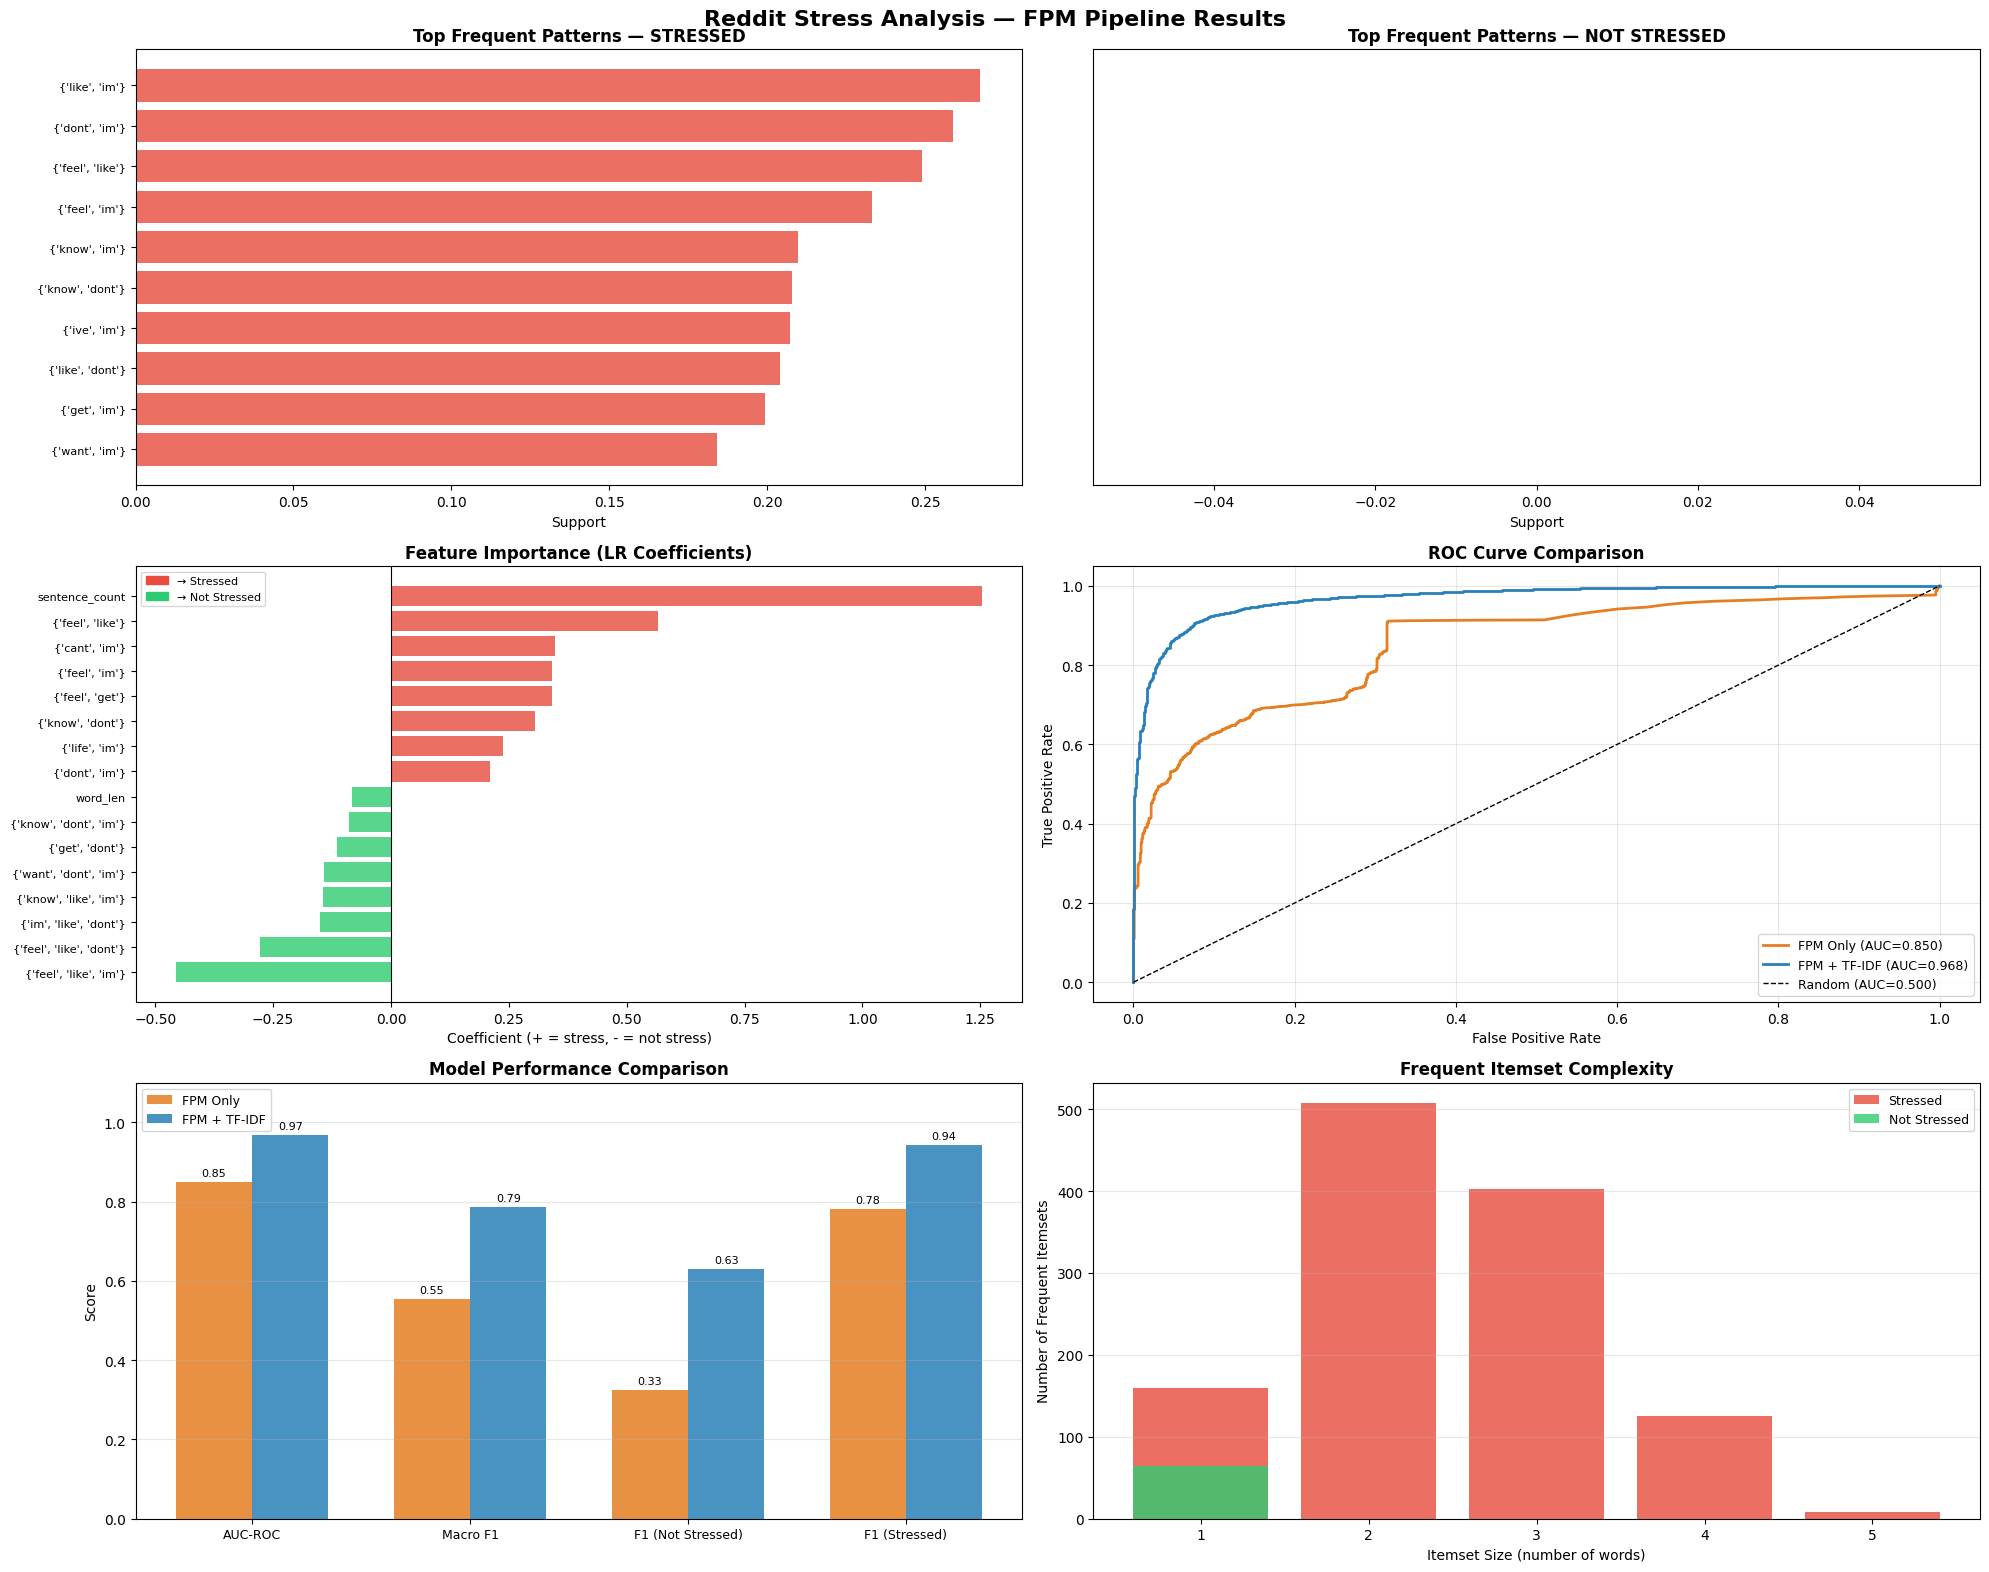


Plot saved as 'fpm_stress_analysis.png'

FINAL PROJECT SUMMARY
Dataset          : 57,231 Reddit posts
Stressed posts   : 52,003 (90.3%)
Not-stressed     : 5,228 (9.7%)

FPM Results:
  Stressed itemsets   : 1,203
  Not-stressed itemsets: 64
  Association rules   : 1,486

Top 3 Stress Linguistic Signals:
  {'like', 'im'} — appears in 26.7% of stressed posts
  {'dont', 'im'} — appears in 25.9% of stressed posts
  {'feel', 'like'} — appears in 24.9% of stressed posts

Model Performance (FPM + TF-IDF):
  AUC-ROC     : 0.9683
  Macro F1    : 0.7862
  Stressed F1 : 0.9425
  Not-Str F1  : 0.6299


In [88]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import roc_curve


import warnings
warnings.filterwarnings('ignore')

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Reddit Stress Analysis — FPM Pipeline Results',
             fontsize=16, fontweight='bold', y=0.98)


ax1 = fig.add_subplot(3, 2, 1)


top_s = freq_items_stressed[freq_items_stressed['length'] >= 2].head(10)
labels_s = [str(set(row['itemsets'])) for _, row in top_s.iterrows()]
supports_s = top_s['support'].values

ax1.barh(range(len(labels_s)), supports_s, color='#e74c3c', alpha=0.8)
ax1.set_yticks(range(len(labels_s)))
ax1.set_yticklabels(labels_s, fontsize=8)
ax1.set_xlabel('Support')
ax1.set_title('Top Frequent Patterns — STRESSED', fontweight='bold')
ax1.invert_yaxis()


ax2 = fig.add_subplot(3, 2, 2)


top_ns = freq_items_not_stressed[freq_items_not_stressed['length'] >= 2].head(10)
labels_ns = [str(set(row['itemsets'])) for _, row in top_ns.iterrows()]
supports_ns = top_ns['support'].values

ax2.barh(range(len(labels_ns)), supports_ns, color='#2ecc71', alpha=0.8)
ax2.set_yticks(range(len(labels_ns)))
ax2.set_yticklabels(labels_ns, fontsize=8)
ax2.set_xlabel('Support')
ax2.set_title('Top Frequent Patterns — NOT STRESSED', fontweight='bold')
ax2.invert_yaxis()


ax3 = fig.add_subplot(3, 2, 3)


top_pos = importance_df.head(8)
top_neg = importance_df.tail(8)
plot_df = pd.concat([top_pos, top_neg])


short_labels = []
for f in plot_df['feature']:
    if 'pat_' in f:

        words = f.split(': ')[1] if ': ' in f else f
        short_labels.append(words)
    else:
        short_labels.append(f)

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in plot_df['coefficient']]
ax3.barh(range(len(plot_df)), plot_df['coefficient'].values, color=colors, alpha=0.8)
ax3.set_yticks(range(len(plot_df)))
ax3.set_yticklabels(short_labels, fontsize=8)
ax3.axvline(x=0, color='black', linewidth=0.8)
ax3.set_xlabel('Coefficient (+ = stress, - = not stress)')
ax3.set_title('Feature Importance (LR Coefficients)', fontweight='bold')
ax3.invert_yaxis()

red_patch   = mpatches.Patch(color='#e74c3c', label='→ Stressed')
green_patch = mpatches.Patch(color='#2ecc71', label='→ Not Stressed')
ax3.legend(handles=[red_patch, green_patch], fontsize=8)


ax4 = fig.add_subplot(3, 2, 4)


fpr1, tpr1, _ = roc_curve(y_test, y_pred_prob)
auc1 = roc_auc_score(y_test, y_pred_prob)


fpr2, tpr2, _ = roc_curve(y_test, y_pred_prob_imp)
auc2 = roc_auc_score(y_test, y_pred_prob_imp)

ax4.plot(fpr1, tpr1, color='#e67e22', lw=2, label=f'FPM Only (AUC={auc1:.3f})')
ax4.plot(fpr2, tpr2, color='#2980b9', lw=2, label=f'FPM + TF-IDF (AUC={auc2:.3f})')
ax4.plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC=0.500)')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve Comparison', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)


ax5 = fig.add_subplot(3, 2, 5)

metrics      = ['AUC-ROC', 'Macro F1', 'F1 (Not Stressed)', 'F1 (Stressed)']
fpm_scores   = [0.8500, 0.5532, 0.3254, 0.7809]
full_scores  = [0.9683, 0.7862, 0.6299, 0.9425]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax5.bar(x - width/2, fpm_scores,  width, label='FPM Only',     color='#e67e22', alpha=0.85)
bars2 = ax5.bar(x + width/2, full_scores, width, label='FPM + TF-IDF', color='#2980b9', alpha=0.85)


for bar in bars1:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax5.set_xticks(x)
ax5.set_xticklabels(metrics, fontsize=9)
ax5.set_ylim(0, 1.1)
ax5.set_ylabel('Score')
ax5.set_title('Model Performance Comparison', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)

ax6 = fig.add_subplot(3, 2, 6)


size_counts = freq_items_stressed['length'].value_counts().sort_index()
ax6.bar(size_counts.index, size_counts.values, color='#e74c3c', alpha=0.8, label='Stressed')


size_counts_ns = freq_items_not_stressed['length'].value_counts().sort_index()
ax6.bar(size_counts_ns.index, size_counts_ns.values,
        color='#2ecc71', alpha=0.8, label='Not Stressed')

ax6.set_xlabel('Itemset Size (number of words)')
ax6.set_ylabel('Number of Frequent Itemsets')
ax6.set_title('Frequent Itemset Complexity', fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(axis='y', alpha=0.3)
ax6.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('fpm_stress_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'fpm_stress_analysis.png'")


print("\n" + "="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)
print(f"Dataset          : {len(df):,} Reddit posts")
print(f"Stressed posts   : {(df['label']==1).sum():,} (90.3%)")
print(f"Not-stressed     : {(df['label']==0).sum():,} (9.7%)")
print(f"\nFPM Results:")
print(f"  Stressed itemsets   : {len(freq_items_stressed):,}")
print(f"  Not-stressed itemsets: {len(freq_items_not_stressed):,}")
print(f"  Association rules   : {len(rules_stressed):,}")
print(f"\nTop 3 Stress Linguistic Signals:")
for _, row in top_stressed_patterns.head(3).iterrows():
    print(f"  {set(row['itemsets'])} — appears in {row['support']*100:.1f}% of stressed posts")
print(f"\nModel Performance (FPM + TF-IDF):")
print(f"  AUC-ROC     : 0.9683")
print(f"  Macro F1    : 0.7862")
print(f"  Stressed F1 : 0.9425")
print(f"  Not-Str F1  : 0.6299")